## Running a Segment of EEG Data ##

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import mne
from scipy.io import loadmat
import sys

sys.path.append("..")
import act as act_cpu_lib

In [2]:
FS = 256
epoch_length = FS
channels = ['HB_1']
order = 5
tc_info = (0, epoch_length, 16)
fc_info = (0.5, 15, 0.5)
logDt_info = (-4, 1, 0.5)
c_info = (-10, 10, 0.5)

In [3]:
data_file = os.path.join(os.getcwd(), '../Testing Scripts/Data/sub-1_task-Sleep_acq-headband_eeg.edf')
raw = mne.io.read_raw_edf(data_file, preload=True, verbose=False)
raw.pick_channels(channels)
raw.notch_filter(50, verbose=False)
raw.filter(l_freq=0.1, h_freq=20.0, verbose=False)
eeg = raw.get_data().T.astype(np.float32)
segment = eeg[:epoch_length,0]
t = np.arange(len(segment))/FS

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


Dictionary length: 185600


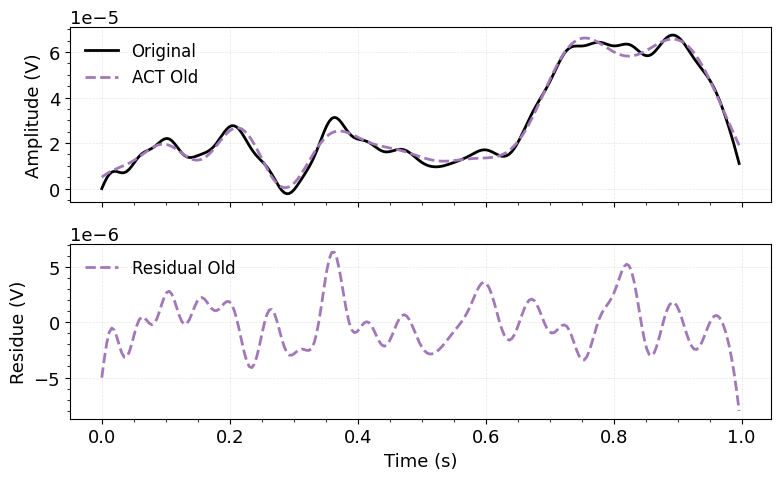

In [4]:
act = act_cpu_lib.ACT(FS=FS, length=epoch_length,
                          tc_info=tc_info, fc_info=fc_info,
                          logDt_info=logDt_info, c_info=c_info,
                          force_regenerate=True, mute=True)

out = act.transform(segment,order=order, debug=False)
plt.rcParams.update({'font.size': 13})
fig,axs = plt.subplots(2,1,figsize=(8,5), sharex= True) 
axs[0].minorticks_on()
axs[0].grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.3)
axs[0].plot(t,out['signal'],label='Original', linewidth=2, color='black')
axs[0].plot(t,out['approx'],'--',label='ACT Old', linewidth=2, color="#A178B8")
axs[0].set_ylabel('Amplitude (V)')
plt.tight_layout(h_pad=0.5)

axs[1].minorticks_on()
axs[1].grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.3)
axs[1].plot(t,out['residue'],'--',label='Residual Old', linewidth=2, color="#A178B8")
axs[1].set_ylabel('Residue (V)')
axs[1].set_xlabel('Time (s)')
plt.tight_layout()

for ax in axs:
    ax.legend(frameon=False, fontsize=12)
    
plt.show()